---
# Modelación Actuarial de Riesgos para Seguro de Casa Habitación

> **Dataset:** `[BASE_SESA]`  
> **Fecha:** `[Mayo 2026]`  
> **Autor:** `[Seguros de Daños Bouclier]`

---
# Índice
**1.** [Definición del producto](#1-definición-del-producto)  
**2.** [Análisis de información inicial](#2-análisis-de-información-inicial)  
**3.** [Prima y cuota de riesgo](#3-prima-y-cuota-de-riesgo)  
**4.** [Cálculo de la cuota de riesgo en función de deducible fijo](#4-cálculo-de-la-cuota-de-riesgo-en-función-de-deducible-fijo)  
**5.** [Procedimientos de la prima de tarifa](#5-procedimientos-de-la-prima-de-tarifa)  

---
## 1. Definición del producto

<table style="border-collapse: collapse; width: 100%;">

<tr style="background-color:#1f2937; color:white;">
    <th style="border:1px solid black; padding:8px;">CAMPO</th>
    <th style="border:1px solid black; padding:8px;">FILTRO SELECCIÓN</th>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">MONEDA</td>
    <td style="border:1px solid black; padding:8px;">Nacional</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">FORMA DE VENTAS</td>
    <td style="border:1px solid black; padding:8px;">TODAS</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">GIRO DE LA UBICACIÓN</td>
    <td style="border:1px solid black; padding:8px;">Casa Habitación</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">NÚMERO DE NIVELES</td>
    <td style="border:1px solid black; padding:8px;">TODOS</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">TIPO PRIMER RIESGO</td>
    <td style="border:1px solid black; padding:8px;">Ninguno</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">ENTIDAD</td>
    <td style="border:1px solid black; padding:8px;">Territorio Nacional</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">SUBTIPO DE SEGURO</td>
    <td style="border:1px solid black; padding:8px;">TODOS</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">TIPO DE BIEN</td>
    <td style="border:1px solid black; padding:8px;">
        Contenidos; Contenidos y Edificio; Edificio
    </td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">COBERTURAS</td>
    <td style="border:1px solid black; padding:8px;">
        Incendio, rayo y explosión; Remoción de Escombros; 
        Gastos Extras para Casa Habitación
    </td>
</tr>

</table>

---
## 2. Análisis de información inicial

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import expon
from scipy.stats import lognorm


# Ruta del archivo Excel
ruta_excel = "BASE_SESA.xlsx"

# Leer únicamente las hojas necesarias
hojas = ["Emisión", "Suma Asegurada", "Siniestros"]

dfs = pd.read_excel(ruta_excel,sheet_name=hojas)

# Guardar cada hoja en un DataFrame independiente
df_emision = dfs["Emisión"]
df_suma_asegurada = dfs["Suma Asegurada"]
df_siniestros = dfs["Siniestros"]

df_emision.info()
df_suma_asegurada.info()
df_siniestros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12627 entries, 0 to 12626
Data columns (total 19 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   MONEDA                                    12627 non-null  object 
 1   FORMA DE VENTA                            12627 non-null  object 
 2   GIRO DE LA UBICACIÓN                      12627 non-null  object 
 3   ENTIDAD                                   12627 non-null  object 
 4   SUBTIPO DE SEGURO                         12627 non-null  object 
 5   NÚMERO DE NIVELES                         12627 non-null  int64  
 6   TIPO PRIMER RIESGO                        12627 non-null  object 
 7   NÚMERO DE UBICACIONES                     12627 non-null  int64  
 8   PRIMA EMITIDA                             12627 non-null  float64
 9   PRIMA RETENIDA                            12627 non-null  float64
 10  PRIMA DEVENGADA EN EL EJERCICIO   

In [11]:
# ============================================
# TABLA RESUMEN 1
# ============================================

# Copias
emision = df_emision.copy()

suma = df_suma_asegurada.copy()

siniestros = df_siniestros.copy()

# Años 
anios = [2020, 2021, 2022, 2023, 2024]

# Filtros
filtro_suma = suma[
    
    # Giro
    suma["GIRO"].astype(str).str.contains(
        "Casa",
        case=False,
        na=False
    ) &
    
    # Tipo de primer riesgo
    suma["TIPO PRIMER RIESGO"].astype(str).str.contains(
        "Ning",
        case=False,
        na=False
    ) &
    
    # Tipo de bien
    suma["TIPO DE BIEN"].astype(str).str.contains(
        "Contenidos|Edificio",
        case=False,
        na=False
    ) &
    
    # Coberturas
    suma["COBERTURA "].astype(str).str.contains(
        "Incendio|Remoción|Gastos Extras",
        case=False,
        na=False
    )
]


# Creamos la tabla

filas = []

# Coberturas
coberturas_reales = filtro_suma["COBERTURA "].unique()

# Tipos de bienes
tipos_bien_reales = filtro_suma["TIPO DE BIEN"].unique()

for cobertura in coberturas_reales:
    
    for tipo in tipos_bien_reales:
        
        temp = filtro_suma[
            (filtro_suma["COBERTURA "] == cobertura) &
            (filtro_suma["TIPO DE BIEN"] == tipo)
        ]
        
        # Si no hay datos, pasamos al siguiente
        if temp.empty:
            continue
        
        fila = {"COBERTURA": cobertura,"TIPO DE BIEN": tipo}
    
        # Ubicaciones
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "NÚMERO DE UBICACIONES"
            ].sum()
            
            fila[f"UBICACIONES_{anio}"] = valor
        
        fila["UBICACIONES_TOTAL"] = temp[
            "NÚMERO DE UBICACIONES"
        ].sum()
        
        # Suma asegurada
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "SUMA ASEGURADA"
            ].sum()
            
            fila[f"SA_{anio}"] = valor
        
        fila["SA_TOTAL"] = temp[
            "SUMA ASEGURADA"
        ].sum()
        
        # Suma asegurada expuesta
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "SUMA ASEGURADA EXPUESTA"
            ].sum()
            
            fila[f"SAE_{anio}"] = valor
        
        fila["SAE_TOTAL"] = temp[
            "SUMA ASEGURADA EXPUESTA"
        ].sum()
        
        filas.append(fila)

# Dataframe 

df_reporte_superior = pd.DataFrame(filas)
pd.set_option("display.max_columns", None)
display(df_reporte_superior)

,COBERTURA,TIPO DE BIEN,UBICACIONES_2020,UBICACIONES_2021,UBICACIONES_2022,UBICACIONES_2023,UBICACIONES_2024,UBICACIONES_TOTAL,SA_2020,SA_2021,SA_2022,SA_2023,SA_2024,SA_TOTAL,SAE_2020,SAE_2021,SAE_2022,SAE_2023,SAE_2024,SAE_TOTAL
0,"Incendio, rayo y explosión",Contenidos,673861,573226,520277,508634,429601,2705599,1909080038558,8058002896332,3681590885260,741766090691,620481592950,15010921503791,47626663545285,1290802007037,1135880723238,606890864179,480491800134,51140728939873
1,"Incendio, rayo y explosión",Edificio,674690,1266418,513799,619481,410535,3484923,2793987430513,23643825276204,8755665297336,2318477460523,2350781624335,39862737088911,82050733170589,3038706556549,2532780537490,1789763637787,1759888022033,91171871924448
2,"Incendio, rayo y explosión",Contenidos y Edificio,417,213,358,317,350,1655,6024289932,3228233532,8164429259,13433523821,22232203505,53082680049,6149304807,3244809962,8332129337,12455496851,17972606512,48154347469
3,Remoción de Escombros,Contenidos,215404,184276,179007,149236,120926,848849,15977877517,12859315909,15110388920,10601559556,13038531019,67587672921,4679820378959,11609587186,13558079553,8974201388,11118637918,4725080885004
4,Remoción de Escombros,Edificio,152349,123960,154744,91828,64579,587460,32424895055,27789775140,51238063678,25800918313,47791198424,185044850610,8062054911268,22805032835,42647434780,19132409006,39503160104,8186142947993
5,Gastos Extras para Casa Habitación,Contenidos,1895,3976,31217,5127,4320,46535,99323618,195416157,690110756,458519589,449263813,1892633933,95942518,192352389,684736280,451708746,443882851,1868622784
6,Gastos Extras para Casa Habitación,Edificio,2,2,0,0,0,4,995436,1023360,0,0,0,2018796,995436,1023360,0,0,0,2018796


In [12]:
# ============================================
# TABLA RESUMEN 2
# ============================================

# Filtro de siniestros

filtro_siniestros = siniestros[
    
    # MONEDA
    siniestros["MONEDA"].astype(str).str.contains(
        "Nacional",
        case=False,
        na=False
    ) &
    
    # Giro
    siniestros["GIRO LA UBICACIÓN"].astype(str).str.contains(
        "Casa",
        case=False,
        na=False
    ) &
    
    # Tipo de primer riesgo
    siniestros["TIPO PRIMER RIESGO"].astype(str).str.contains(
        "Ning",
        case=False,
        na=False
    ) &
    
    # Tipo de bien
    siniestros["TIPO DE BIEN"].astype(str).str.contains(
        "Contenidos|Edificio",
        case=False,
        na=False
    ) &
    
    # Cobertura
    siniestros["COBERTURA"].astype(str).str.contains(
        "Incendio|Remoción|Gastos Extras",
        case=False,
        na=False
    )
]

# Creamos la tabla

filas_sin = []

coberturas_sin = filtro_siniestros["COBERTURA"].unique()

tipos_sin = filtro_siniestros["TIPO DE BIEN"].unique()

for cobertura in coberturas_sin:
    
    for tipo in tipos_sin:
        
        temp = filtro_siniestros[
            (filtro_siniestros["COBERTURA"] == cobertura) &
            (filtro_siniestros["TIPO DE BIEN"] == tipo)
        ]
        
        if temp.empty:
            continue
        
        fila = {"COBERTURA": cobertura,"TIPO DE BIEN": tipo}
        
        # Siniestros
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "NÚMERO DE SINIESTROS"
            ].sum()
            
            fila[f"SINIESTROS_{anio}"] = valor
        
        fila["SINIESTROS_TOTAL"] = temp[
            "NÚMERO DE SINIESTROS"
        ].sum()
        
        # Monto pagado
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "MONTO PAGADO"
            ].sum()
            
            fila[f"PAGADO_{anio}"] = valor
        
        fila["PAGADO_TOTAL"] = temp[
            "MONTO PAGADO"
        ].sum()
        
        # Mondo del siniestro
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "MONTO DE SINIESTRO"
            ].sum()
            
            fila[f"OCURRIDO_{anio}"] = valor
        
        fila["OCURRIDO_TOTAL"] = temp[
            "MONTO DE SINIESTRO"
        ].sum()
        
        filas_sin.append(fila)

# Dataframe

df_siniestros_resumen = pd.DataFrame(filas_sin)
display(df_siniestros_resumen)

,COBERTURA,TIPO DE BIEN,SINIESTROS_2020,SINIESTROS_2021,SINIESTROS_2022,SINIESTROS_2023,SINIESTROS_2024,SINIESTROS_TOTAL,PAGADO_2020,PAGADO_2021,PAGADO_2022,PAGADO_2023,PAGADO_2024,PAGADO_TOTAL,OCURRIDO_2020,OCURRIDO_2021,OCURRIDO_2022,OCURRIDO_2023,OCURRIDO_2024,OCURRIDO_TOTAL
0,"Incendio, rayo y explosión",Edificio,1448,1696,1705,1817,2018,8684,"39,613,237.400000","76,745,014.070000","77,540,514.880000","66,314,143.430000","79,179,491.060000","339,392,400.840000","28,931,439.970000","103,998,440.730000","94,301,268.670000","37,268,776.300000","74,696,251.750000","339,196,177.420000"
1,"Incendio, rayo y explosión",Contenidos,701,867,837,933,976,4314,"14,152,908.670000","41,559,932.440000","69,112,734.740000","12,522,627.800000","18,613,666.370000","155,961,870.020000","16,286,686.070000","90,820,243.420000","21,179,211.770000","11,870,158.280000","21,493,858.400000","161,650,157.940000"
2,"Incendio, rayo y explosión",Contenidos y Edificio,4,1,1,0,1,7,"89,604.930000","78,469.800000","27,450.000000",0.000000,0.000000,"195,524.730000","-51,050.100000","-21,530.200000","27,450.000000",0.000000,"27,010.000000","-18,120.300000"
3,Remoción de Escombros,Edificio,38,36,32,51,179,336,"547,158.540000","600,110.040000","1,415,858.850000","1,409,319.140000","3,608,496.010000","7,580,942.580000","641,088.090000","691,636.470000","1,520,598.850000","2,668,707.230000","4,030,658.970000","9,552,689.610000"
4,Remoción de Escombros,Contenidos,2,3,4,7,7,23,"21,647.500000","27,600.000000","33,580.000000","164,854.700000","191,555.490000","439,237.690000","21,647.500000","29,567.000000","51,030.000000","283,449.700000","267,990.490000","653,684.690000"
5,Gastos Extras para Casa Habitación,Edificio,1,0,2,1,0,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"3,000.000000","-3,000.000000",0.000000,0.000000
6,Gastos Extras para Casa Habitación,Contenidos,0,0,1,1,0,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"7,000.000000","-7,000.000000",0.000000,0.000000


In [13]:
# ============================================
# TABLA RESUMEN 3
# ============================================

# Filtro emisión

filtro_emision = emision[
    
    # Giro
    emision["GIRO DE LA UBICACIÓN"].astype(str).str.contains(
        "Casa",
        case=False,
        na=False
    ) &
    
    # Tipo de primer riesgo
    emision["TIPO PRIMER RIESGO"].astype(str).str.contains(
        "Ning",
        case=False,
        na=False
    )
].copy()

# Clasificamos por tipo de bien

def clasificar_tipo_bien(row):
    
    edificio = row["VALORES TOTALES EDIFICIO"]
    contenido = row["VALORES TOTALES CONTENIDO"]
    
    # Validamos nulos
    
    edificio = 0 if pd.isna(edificio) else edificio
    
    contenido = 0 if pd.isna(contenido) else contenido
    
    if edificio > 0 and contenido > 0:
        return "Contenidos y Edificio"
    
    elif edificio > 0:
        return "Edificio"
    
    elif contenido > 0:
        return "Contenidos"
    
    else:
        return "Sin Clasificar"

# Creamos como columna nueva

filtro_emision["TIPO DE BIEN"] = filtro_emision.apply(
    clasificar_tipo_bien,
    axis=1
)

# Filtramos 

filtro_emision_tb = filtro_emision[
    filtro_emision["TIPO DE BIEN"].isin([
        "Contenidos",
        "Edificio",
        "Contenidos y Edificio"
    ])
]

# Creamos la tabla

filas_emi = []

tipos_bien = [
    "Contenidos",
    "Edificio",
    "Contenidos y Edificio"
]

for tipo in tipos_bien:
    
    temp = filtro_emision_tb[
        filtro_emision_tb["TIPO DE BIEN"] == tipo
    ]
    
    # Si no hay datos
    
    if temp.empty:
        continue
    
    fila = {"TIPO DE BIEN": tipo}
    
    # Prima emitida
    
    for anio in anios:
        
        valor = temp.loc[
            temp["AÑO"] == anio,
            "PRIMA EMITIDA"
        ].sum()
        
        fila[f"PRIMA_{anio}"] = valor
    
    fila["PRIMA_TOTAL"] = temp[
        "PRIMA EMITIDA"
    ].sum()
    
    # Prima devengada
    
    for anio in anios:
        
        valor = temp.loc[
            temp["AÑO"] == anio,
            "PRIMA DEVENGADA EN EL EJERCICIO"
        ].sum()
        
        fila[f"DEVENGADA_{anio}"] = valor
    
    fila["DEVENGADA_TOTAL"] = temp[
        "PRIMA DEVENGADA EN EL EJERCICIO"
    ].sum()
    
    # Numero de ubicaciones
    
    for anio in anios:
        
        valor = temp.loc[
            temp["AÑO"] == anio,
            "NÚMERO DE UBICACIONES"
        ].sum()
        
        fila[f"UBICACIONES_{anio}"] = valor
    
    fila["UBICACIONES_TOTAL"] = temp[
        "NÚMERO DE UBICACIONES"
    ].sum()
    
    filas_emi.append(fila)

# Dataframe

df_primas_resumen = pd.DataFrame(filas_emi)

pd.set_option(
    "display.max_columns",
    None
)

display(df_primas_resumen)

,TIPO DE BIEN,PRIMA_2020,PRIMA_2021,PRIMA_2022,PRIMA_2023,PRIMA_2024,PRIMA_TOTAL,DEVENGADA_2020,DEVENGADA_2021,DEVENGADA_2022,DEVENGADA_2023,DEVENGADA_2024,DEVENGADA_TOTAL,UBICACIONES_2020,UBICACIONES_2021,UBICACIONES_2022,UBICACIONES_2023,UBICACIONES_2024,UBICACIONES_TOTAL
0,Contenidos,"95,744,075.870000","1,461,269.610000","1,381,403.990000","41,186,241.870000","32,683,705.710000","172,456,697.050000","96,820,321.930000","1,457,146.250000","1,363,786.560000","41,252,873.170000","32,761,382.000000","173,655,509.910000",243,291,335,623,1008,2500
1,Edificio,"284,740.050000","666,275.020000","383,786.200000","1,371,169.100000","621,590.000000","3,327,560.370000","264,109.780000","495,310.590000","191,287.110000","921,919.440000","905,427.600000","2,778,054.520000",471,543,1334,1046,309,3703
2,Contenidos y Edificio,"438,621,051.640000","605,368,090.520000","478,264,430.990000","474,405,350.490000","497,219,457.500000","2,493,878,381.140000","388,039,273.350000","626,556,892.640000","473,726,056.230000","499,276,494.370000","496,286,255.350000","2,483,884,971.940000",802135,1506085,681801,799890,598294,4388205


---
## 3. Prima y cuota de riesgo

### Metodología de Frecuencia, Severidad y Prima de Riesgo

La información presentada en las tablas siguientes se obtiene mediante una selección y discriminación de información con el objetivo de desarrollar la Nota Técnica del producto, permitiendo un adecuado orden y selección del riesgo.

### Frecuencia

La frecuencia representa la proporción de siniestros respecto al número de ubicaciones expuestas al riesgo.

$$
Frecuencia_{i,j} =
\frac{
\text{Número de Siniestros}_{i,j}
}{
\text{Número de Ubicaciones}_{i,j}
}
$$

Donde:

- $i$: Año
- $j$: Tipo de Bien / Cobertura

---

### Severidad

La severidad se calcula considerando tanto la siniestralidad ocurrida como la siniestralidad pagada, con el objetivo de evaluar la mejor aproximación para la estimación del costo del riesgo.

#### Severidad Ocurrida

$$
Severidad_{Ocurrida,i,j} =
\frac{
\text{Monto de Siniestros Ocurridos}_{i,j}
}{
\text{Número de Siniestros}_{i,j}
}
$$

#### Severidad Pagada

$$
Severidad_{Pagada,i,j} =
\frac{
\text{Monto de Siniestros Pagados}_{i,j}
}{
\text{Número de Siniestros}_{i,j}
}
$$

---

### Prima de Riesgo

Finalmente, se obtiene la Prima de Riesgo mediante el producto de la frecuencia y la severidad.

#### Prima de Riesgo Ocurrida

$$
PR_{Ocurrida,i,j} =
Frecuencia_{i,j}
\cdot
Severidad_{Ocurrida,i,j}
$$

#### Prima de Riesgo Pagada

$$
PR_{Pagada,i,j} =
Frecuencia_{i,j}
\cdot
Severidad_{Pagada,i,j}
$$

Donde:

$$
PR_{tip,i}
$$

representa la prima de riesgo considerando siniestralidad ocurrida o siniestralidad pagada.

---

### Cuota de Riesgo (al millar)

La Cuota de Riesgo considera la relación entre el monto de siniestros y la suma asegurada expuesta.

#### Cuota de Riesgo Ocurrida

$$
CR_{Ocurrida,i,j} =
\frac{
\text{Monto de Siniestros Ocurridos}_{i,j}
}{
\text{Suma Asegurada Expuesta}_{i,j}
}
\cdot 1000
$$

#### Cuota de Riesgo Pagada

$$
CR_{Pagada,i,j} =
\frac{
\text{Monto de Siniestros Pagados}_{i,j}
}{
\text{Suma Asegurada Expuesta}_{i,j}
}
\cdot 1000
$$

---

### Selección de Cuota de Riesgo

Finalmente, se realiza la selección de la cuota de riesgo máxima entre la ocurrida y la pagada.

$$
CR_i =
\max
\left\{
CR_{Ocurrida,i,j},
\,
CR_{Pagada,i,j}
\right\}
$$

In [14]:
# ============================================
# CALCULO DE FRECUENCIA, SEVERIDAD,
# PRIMA DE RIESGO Y CUOTA DE RIESGO
# ============================================

# Creamos la tabla base

base = pd.merge(
    df_reporte_superior,
    df_siniestros_resumen,
    on=["COBERTURA", "TIPO DE BIEN"],
    how="left"
)

# Cálculos

filas_metricas = []

for _, row in base.iterrows():
    
    fila = {
        "COBERTURA": row["COBERTURA"],
        "TIPO DE BIEN": row["TIPO DE BIEN"]
    }
    
    for anio in anios:
        
        # Variables
        
        ubicaciones = row.get(f"UBICACIONES_{anio}", 0)
        
        siniestros = row.get(f"SINIESTROS_{anio}", 0)
        
        ocurrido = row.get(f"OCURRIDO_{anio}", 0)
        
        pagado = row.get(f"PAGADO_{anio}", 0)
        
        sae = row.get(f"SAE_{anio}", 0)
        
        # Frecuencia
        
        frecuencia = (
            siniestros / ubicaciones
            if ubicaciones != 0
            else 0
        )
        
        # Severidad
        
        severidad_ocurrida = (
            ocurrido / siniestros
            if siniestros != 0
            else 0
        )
        
        severidad_pagada = (
            pagado / siniestros
            if siniestros != 0
            else 0
        )
        
        # Prima de riesgo
        
        pr_ocurrida = (
            frecuencia * severidad_ocurrida
        )
        
        pr_pagada = (
            frecuencia * severidad_pagada
        )
        
        # Cuota de riesgo
        
        cr_ocurrida = (
            (ocurrido / sae) * 1000
            if sae != 0
            else 0
        )
        
        cr_pagada = (
            (pagado / sae) * 1000
            if sae != 0
            else 0
        )
        
        cr_max = max(
            cr_ocurrida,
            cr_pagada
        )
        
        # Guardamos resultados
        
        fila[f"FRECUENCIA_{anio}"] = frecuencia
        
        fila[f"SEV_OCURRIDA_{anio}"] = severidad_ocurrida
        
        fila[f"SEV_PAGADA_{anio}"] = severidad_pagada
        
        fila[f"PR_OCURRIDA_{anio}"] = pr_ocurrida
        
        fila[f"PR_PAGADA_{anio}"] = pr_pagada
        
        fila[f"CR_OCURRIDA_{anio}"] = cr_ocurrida
        
        fila[f"CR_PAGADA_{anio}"] = cr_pagada
        
        fila[f"CR_MAX_{anio}"] = cr_max
    
    filas_metricas.append(fila)

# Dataframe

df_metricas = pd.DataFrame(filas_metricas)
display(df_metricas)

,COBERTURA,TIPO DE BIEN,FRECUENCIA_2020,SEV_OCURRIDA_2020,SEV_PAGADA_2020,PR_OCURRIDA_2020,PR_PAGADA_2020,CR_OCURRIDA_2020,CR_PAGADA_2020,CR_MAX_2020,FRECUENCIA_2021,SEV_OCURRIDA_2021,SEV_PAGADA_2021,PR_OCURRIDA_2021,PR_PAGADA_2021,CR_OCURRIDA_2021,CR_PAGADA_2021,CR_MAX_2021,FRECUENCIA_2022,SEV_OCURRIDA_2022,SEV_PAGADA_2022,PR_OCURRIDA_2022,PR_PAGADA_2022,CR_OCURRIDA_2022,CR_PAGADA_2022,CR_MAX_2022,FRECUENCIA_2023,SEV_OCURRIDA_2023,SEV_PAGADA_2023,PR_OCURRIDA_2023,PR_PAGADA_2023,CR_OCURRIDA_2023,CR_PAGADA_2023,CR_MAX_2023,FRECUENCIA_2024,SEV_OCURRIDA_2024,SEV_PAGADA_2024,PR_OCURRIDA_2024,PR_PAGADA_2024,CR_OCURRIDA_2024,CR_PAGADA_2024,CR_MAX_2024
0,"Incendio, rayo y explosión",Contenidos,0.001040,"23,233.503666","20,189.598673",24.169207,21.002712,0.000342,0.000297,0.000342,0.001512,"104,752.299216","47,935.331534",158.437062,72.501827,0.070360,0.032197,0.070360,0.001609,"25,303.717766","82,571.965042",40.707569,132.838343,0.018646,0.060845,0.060845,0.001834,"12,722.570504","13,421.894748",23.337328,24.620115,0.019559,0.020634,0.020634,0.002272,"22,022.395902","19,071.379477",50.032142,43.327800,0.044733,0.038739,0.044733
1,"Incendio, rayo y explosión",Edificio,0.002146,"19,980.276222","27,357.208149",42.881086,58.713242,0.000353,0.000483,0.000483,0.001339,"61,319.835336","45,250.597919",82.120154,60.600066,0.034225,0.025256,0.034225,0.003318,"55,308.661977","45,478.307848",183.537276,150.916049,0.037232,0.030615,0.037232,0.002933,"20,511.159218","36,496.501613",60.161290,107.047905,0.020823,0.037052,0.037052,0.004916,"37,014.990956","39,236.615986",181.948559,192.869039,0.042444,0.044991,0.044991
2,"Incendio, rayo y explosión",Contenidos y Edificio,0.009592,"-12,762.525000","22,401.232500",-122.422302,214.879928,-0.008302,0.014572,0.014572,0.004695,"-21,530.200000","78,469.800000",-101.080751,368.402817,-0.006635,0.024183,0.024183,0.002793,"27,450.000000","27,450.000000",76.675978,76.675978,0.003294,0.003294,0.003294,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002857,"27,010.000000",0.000000,77.171429,0.000000,0.001503,0.000000,0.001503
3,Remoción de Escombros,Contenidos,0.000009,"10,823.750000","10,823.750000",0.100497,0.100497,0.000005,0.000005,0.000005,0.000016,"9,855.666667","9,200.000000",0.160450,0.149775,0.002547,0.002377,0.002547,0.000022,"12,757.500000","8,395.000000",0.285073,0.187590,0.003764,0.002477,0.003764,0.000047,"40,492.814286","23,550.671429",1.899339,1.104658,0.031585,0.018370,0.031585,0.000058,"38,284.355714","27,365.070000",2.216153,1.584072,0.024103,0.017228,0.024103
4,Remoción de Escombros,Edificio,0.000249,"16,870.739211","14,398.908947",4.208023,3.591481,0.000080,0.000068,0.000080,0.000290,"19,212.124167","16,669.723333",5.579513,4.841159,0.030328,0.026315,0.030328,0.000207,"47,518.714063","44,245.589063",9.826545,9.149685,0.035655,0.033199,0.035655,0.000555,"52,327.592745","27,633.708627",29.062021,15.347379,0.139486,0.073661,0.139486,0.002772,"22,517.647877","20,159.195587",62.414391,55.877236,0.102034,0.091347,0.102034
5,Gastos Extras para Casa Habitación,Contenidos,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000032,"7,000.000000",0.000000,0.224237,0.000000,0.010223,0.000000,0.010223,0.000195,"-7,000.000000",0.000000,-1.365321,0.000000,-0.015497,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Gastos Extras para Casa Habitación,Edificio,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"1,500.000000",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"-3,000.000000",0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


---
## 4. Cálculo de la cuota de riesgo en función de deducible fijo

Se realiza la estimación de la función de pérdida de riesgos individuales, suponiendo que la información histórica de los años puede convertirse a siniestros individuales. Esto consiste en realizar el cociente entre el monto de siniestro (ocurrido o pagado) y el número de siniestros.

### Aproximación de severidad individual ocurrida

$$
Xaprox_{Ocurrida,i} =
\frac{
Siniestros\ Ocurridos_i
}{
Número\ de\ Siniestros_i
}
$$

### Aproximación de severidad individual pagada

$$
Xaprox_{Pagada,i} =
\frac{
Siniestros\ Pagados_i
}{
Número\ de\ Siniestros_i
}
$$

Donde:

- $i$: Registro $i$ de la compilación de datos.

Se obtiene la función de distribución de densidad para el total de la información y se supone una distribución exponencial para dichas pérdidas.

In [15]:
# ============================================
# CALCULO DE Xaprox
# SEVERIDAD INDIVIDUAL APROXIMADA
# ============================================

# Base

base_x = df_siniestros_resumen.copy()

# Cálculos

filas_x = []

for _, row in base_x.iterrows():
    
    fila = {
        "COBERTURA": row["COBERTURA"],
        "TIPO DE BIEN": row["TIPO DE BIEN"]
    }
    
    for anio in anios:
        
        # Variables
        
        num_sin = row.get(
            f"SINIESTROS_{anio}",
            0
        )
        
        monto_ocurrido = row.get(
            f"OCURRIDO_{anio}",
            0
        )
        
        monto_pagado = row.get(
            f"PAGADO_{anio}",
            0
        )
        
        # X Aprox ocurrida
        
        xaprox_ocurrida = (
            monto_ocurrido / num_sin
            if num_sin != 0
            else 0
        )
        
        # X Aprox Pagada
        
        xaprox_pagada = (
            monto_pagado / num_sin
            if num_sin != 0
            else 0
        )
        
        # Guardamos
        
        fila[f"XAPROX_OCURRIDA_{anio}"] = (
            xaprox_ocurrida
        )
        
        fila[f"XAPROX_PAGADA_{anio}"] = (
            xaprox_pagada
        )
    
    filas_x.append(fila)

# Dataframe

df_xaprox = pd.DataFrame(filas_x)
display(df_xaprox)

,COBERTURA,TIPO DE BIEN,XAPROX_OCURRIDA_2020,XAPROX_PAGADA_2020,XAPROX_OCURRIDA_2021,XAPROX_PAGADA_2021,XAPROX_OCURRIDA_2022,XAPROX_PAGADA_2022,XAPROX_OCURRIDA_2023,XAPROX_PAGADA_2023,XAPROX_OCURRIDA_2024,XAPROX_PAGADA_2024
0,"Incendio, rayo y explosión",Edificio,"19,980.276222","27,357.208149","61,319.835336","45,250.597919","55,308.661977","45,478.307848","20,511.159218","36,496.501613","37,014.990956","39,236.615986"
1,"Incendio, rayo y explosión",Contenidos,"23,233.503666","20,189.598673","104,752.299216","47,935.331534","25,303.717766","82,571.965042","12,722.570504","13,421.894748","22,022.395902","19,071.379477"
2,"Incendio, rayo y explosión",Contenidos y Edificio,"-12,762.525000","22,401.232500","-21,530.200000","78,469.800000","27,450.000000","27,450.000000",0.000000,0.000000,"27,010.000000",0.000000
3,Remoción de Escombros,Edificio,"16,870.739211","14,398.908947","19,212.124167","16,669.723333","47,518.714063","44,245.589063","52,327.592745","27,633.708627","22,517.647877","20,159.195587"
4,Remoción de Escombros,Contenidos,"10,823.750000","10,823.750000","9,855.666667","9,200.000000","12,757.500000","8,395.000000","40,492.814286","23,550.671429","38,284.355714","27,365.070000"
5,Gastos Extras para Casa Habitación,Edificio,0.000000,0.000000,0.000000,0.000000,"1,500.000000",0.000000,"-3,000.000000",0.000000,0.000000,0.000000
6,Gastos Extras para Casa Habitación,Contenidos,0.000000,0.000000,0.000000,0.000000,"7,000.000000",0.000000,"-7,000.000000",0.000000,0.000000,0.000000


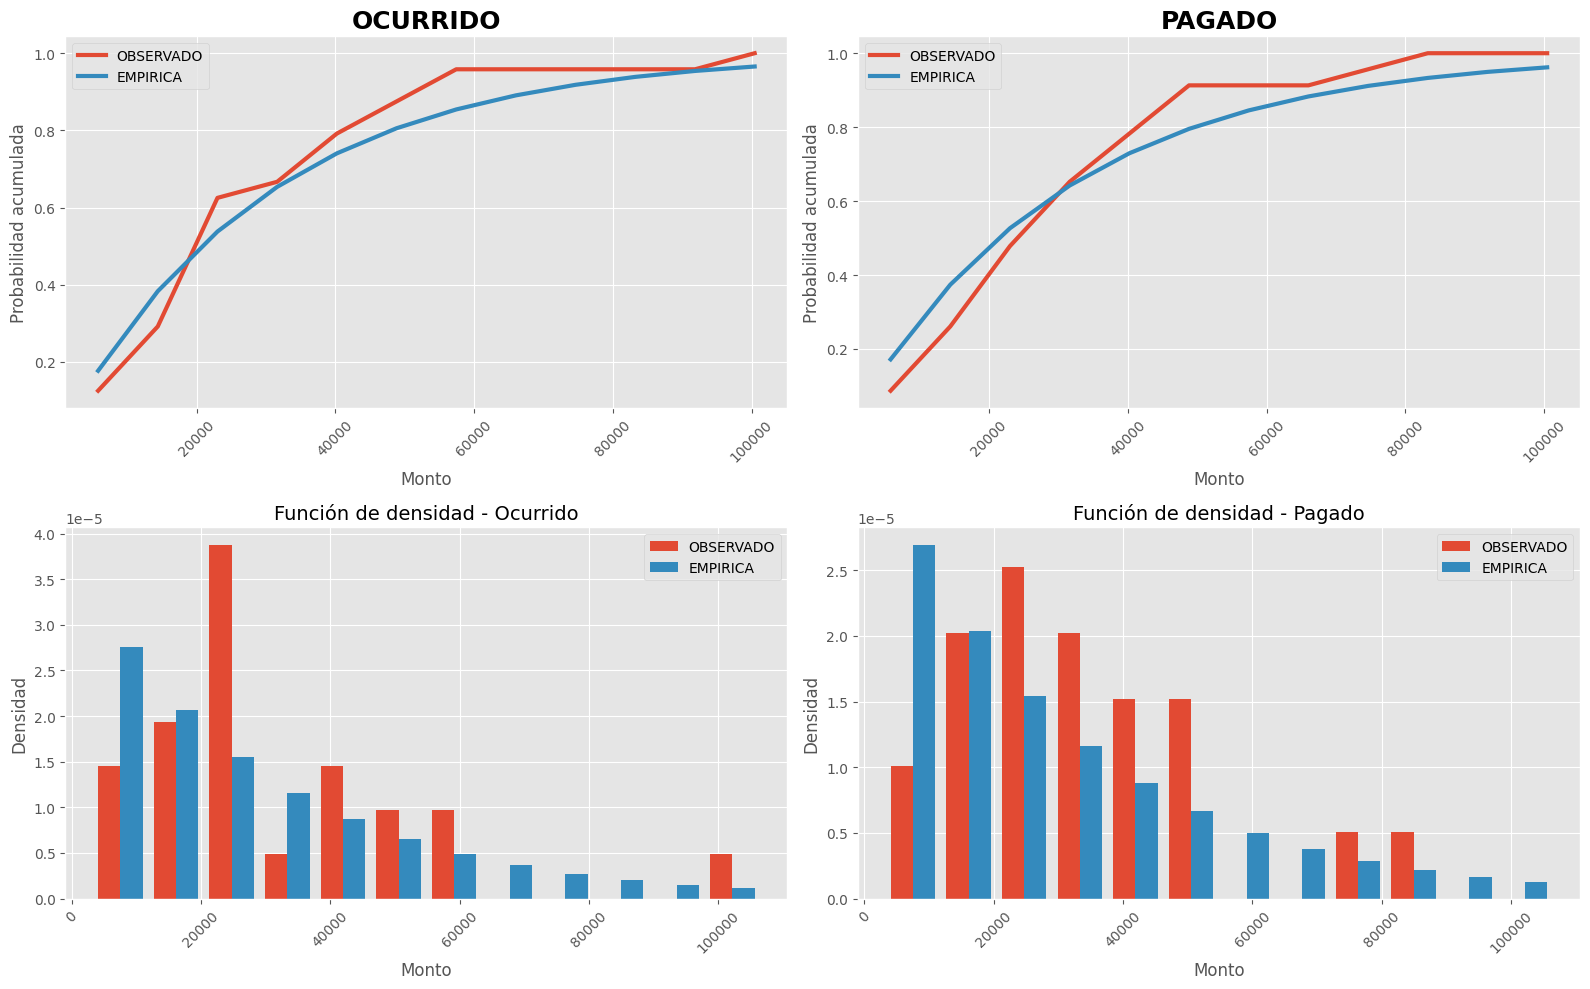

In [16]:
# ============================================
# GRAFICAS DISTRIBUCION EMPIRICA VS OBSERVADA
# ============================================

# Estilo ggplot de R
plt.style.use("ggplot")

# Datos

x_ocurrida = []

x_pagada = []

for _, row in df_xaprox.iterrows():
    
    for anio in anios:
        
        xo = row.get(
            f"XAPROX_OCURRIDA_{anio}",
            0
        )
        
        xp = row.get(
            f"XAPROX_PAGADA_{anio}",
            0
        )
        
        if xo > 0:
            x_ocurrida.append(xo)
        
        if xp > 0:
            x_pagada.append(xp)

x_ocurrida = np.array(x_ocurrida)

x_pagada = np.array(x_pagada)

# Intervalos del histograma

bins = np.histogram_bin_edges(
    np.concatenate([x_ocurrida, x_pagada]),
    bins=12
)

# Distrubución Empirica

hist_occ, edges = np.histogram(
    x_ocurrida,
    bins=bins,
    density=True
)

hist_pag, _ = np.histogram(
    x_pagada,
    bins=bins,
    density=True
)

# Distrubución Exponencial

lambda_occ = 1 / np.mean(x_ocurrida)

lambda_pag = 1 / np.mean(x_pagada)

# Centros

centros = (edges[:-1] + edges[1:]) / 2

# Densidad

dens_occ = expon.pdf(
    centros,
    scale=1/lambda_occ
)

dens_pag = expon.pdf(
    centros,
    scale=1/lambda_pag
)

# Acumulada

cdf_occ = expon.cdf(
    centros,
    scale=1/lambda_occ
)

cdf_pag = expon.cdf(
    centros,
    scale=1/lambda_pag
)

# Empirica acumulada

emp_occ = np.cumsum(hist_occ)

emp_occ = emp_occ / emp_occ.max()

emp_pag = np.cumsum(hist_pag)

emp_pag = emp_pag / emp_pag.max()


# Gráficas

fig, axs = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

# Ocurrido acumulada

axs[0,0].plot(
    centros,
    emp_occ,
    linewidth=3,
    label="OBSERVADO"
)

axs[0,0].plot(
    centros,
    cdf_occ,
    linewidth=3,
    label="EMPIRICA"
)

axs[0,0].set_title(
    "OCURRIDO",
    fontsize=18,
    fontweight="bold"
)

axs[0,0].set_xlabel(
    "Monto"
)

axs[0,0].set_ylabel(
    "Probabilidad acumulada"
)

axs[0,0].legend()

# Pagado acumulada

axs[0,1].plot(
    centros,
    emp_pag,
    linewidth=3,
    label="OBSERVADO"
)

axs[0,1].plot(
    centros,
    cdf_pag,
    linewidth=3,
    label="EMPIRICA"
)

axs[0,1].set_title(
    "PAGADO",
    fontsize=18,
    fontweight="bold"
)

axs[0,1].set_xlabel(
    "Monto"
)

axs[0,1].set_ylabel(
    "Probabilidad acumulada"
)

axs[0,1].legend()

# Ocurrido densidad

width = np.diff(edges)

axs[1,0].bar(
    centros,
    hist_occ,
    width=width*0.4,
    label="OBSERVADO"
)

axs[1,0].bar(
    centros + width*0.4,
    dens_occ,
    width=width*0.4,
    label="EMPIRICA"
)

axs[1,0].set_title(
    "Función de densidad - Ocurrido",
    fontsize=14
)

axs[1,0].set_xlabel(
    "Monto"
)

axs[1,0].set_ylabel(
    "Densidad"
)

axs[1,0].legend()

# Pagado Densidad

axs[1,1].bar(
    centros,
    hist_pag,
    width=width*0.4,
    label="OBSERVADO"
)

axs[1,1].bar(
    centros + width*0.4,
    dens_pag,
    width=width*0.4,
    label="EMPIRICA"
)

axs[1,1].set_title(
    "Función de densidad - Pagado",
    fontsize=14
)

axs[1,1].set_xlabel(
    "Monto"
)

axs[1,1].set_ylabel(
    "Densidad"
)

axs[1,1].legend()

# Formato

for ax in axs.flat:
    
    ax.grid(True)
    
    ax.tick_params(
        axis='x',
        rotation=45
    )

plt.tight_layout()

plt.show()

---
## 5. Procedimientos de la prima de tarifa


- Gastos de administración  
- Gastos de adquisición  
- Margen de utilidad  

$$
Prima\ de\ Tarifa
=
Prima\ de\ Riesgo
+
Gastos\ de\ Administración
+
Gastos\ de\ Adquisición
+
Margen\ de\ Utilidad
$$

$$
Prima\ de\ Riesgo
=
SA \times CR
$$

Generalmente los gastos se expresan en términos de la denominada prima de tarifa.

$$
PT
=
PR
+
\%Adm \times PT
+
\%Adq \times PT
+
\%Mu \times PT
$$

$$
\%Gastos\ de\ Administración
=
\frac{
Costo\ de\ Operación
}{
Prima\ Emitida
}
$$

$$
\%Gastos\ de\ Adquisición
=
\frac{
Gasto\ de\ Adquisición
}{
Prima\ Emitida
}
$$

$$
PT
=
PR
+
[\%Adm + \%Adq + \%Mu] \times PT
$$

$$
PT
=
\frac{
PR
}{
1 - [\%Adm + \%Adq + \%Mu]
}
$$

### Cargos adicionales que se hacen

### Derechos de póliza

Se cobra como un gasto directo.

- Papeles inmediatos del seguro  
  (Póliza, contenedores, papelería, etc.)

###Recargo por pago fraccionado para financiar la prima

Si el asegurado decide realizar pagos iguales de monto \(R\) para cubrir el costo del seguro, entonces la compañía financia el pago fraccionado utilizando para ello una tasa de interés \(i\).

### El factor \(f\)

$$
f
=
\frac{
m
}{
\sum_{k=0}^{m-1}
\left(
1+\frac{j}{m}
\right)^{-k}
}
$$

Dicho factor \(f\) cumple con:

$$
R
=
\frac{
PyG
}{
m
}
$$

$$
PyG
=
PyG_0 \times f
$$

$$
\sum_{k=0}^{m-1}
R
*
\left(
1+\frac{j}{m}
\right)^{-k}
=
PyG
$$

donde:

- \(\frac{j}{m}\) = tasa efectiva mensual  
- \(j\) = tasa de interés anual

In [ ]:
# ============================================
# CALCULO DE PRIMA DE TARIFA
# ============================================

# Supuestos tecnicos

gasto_admin = 0.20

gasto_adquisicion = 0.05

margen_utilidad = 0.06

# Tasa anual para recargo financiero

j = 0.08

# Numero de pagos fraccionados

m = 12

# Factor de financiamiento

factor_financiero = (
    
    m /
    
    sum(
        (
            1 + (j / m)
        ) ** (-k)
        
        for k in range(m)
    )
)

# Porcentaje total

cargos = (gasto_admin + gasto_adquisicion + margen_utilidad )

# Calculo de prima de tarifa

filas_tarifa = []

for _, row in df_metricas.iterrows():
    
    fila = {
        "COBERTURA": row["COBERTURA"],
        "TIPO DE BIEN": row["TIPO DE BIEN"]
    }
    
    for anio in anios:
        
        # Cuota de riesgo
        
        cr = row.get(
            f"CR_MAX_{anio}",
            0
        )

        # Prima de riesgo
        
        pr = row.get(
            f"PR_OCURRIDA_{anio}",
            0
        )
        
        # Validacion de nulos
        
        cr = (
            0
            if pd.isna(cr)
            else cr
        )
        
        pr = (
            0
            if pd.isna(pr)
            else pr
        )
        
        # Validacion de negativos
        
        # En seguros no puede existir:
        # prima negativa
        # cuota negativa
        
        pr = max(pr, 0)
        
        cr = max(cr, 0)
        
        # Validacion de experiencia
        
        # Si no existe experiencia
        # dejamos tarifa en cero
        
        if pr == 0:
            
            pt = 0
            
            pt_recargo = 0
            
            recibo_mensual = 0
            
            gasto_admin_pt = 0
            
            gasto_adq_pt = 0
            
            margen_utilidad_pt = 0
        
        else:
            
            # Prima de tarifa
            
            # Formula:
            #
            # PT = PR / (1 - gastos)
            
            pt = (
                
                pr /
                
                (1 - cargos)
                
            )
            
            # Recargo financiero
            
            pt_recargo = (
                
                pt *
                factor_financiero
                
            )

            # Recibo mensual
            
            recibo_mensual = (
                
                pt_recargo / m
                
            )
            
            # Desgloce de datos
            
            gasto_admin_pt = (
                
                pt *
                gasto_admin
                
            )
            
            gasto_adq_pt = (
                
                pt *
                gasto_adquisicion
                
            )
            
            margen_utilidad_pt = (
                
                pt *
                margen_utilidad
                
            )
        
        # Relacion prima - cuota
        
        # Prima por millar
        
        prima_millar = (
            
            cr *
            (1 / (1 - cargos))
            
        )
        
        # Recargo financiero
        
        recargo_pct = (
            
            (
                pt_recargo / pt
            ) - 1
            
            if pt != 0
            else 0
        )
        
        # Guardamos los resultados
        
        fila[f"CR_{anio}"] = cr
        
        fila[f"PR_{anio}"] = pr
        
        fila[f"PT_{anio}"] = pt
        
        fila[f"PT_RECARGO_{anio}"] = pt_recargo
        
        fila[f"RECIBO_MENSUAL_{anio}"] = recibo_mensual
        
        fila[f"PRIMA_MILLAR_{anio}"] = prima_millar
        
        fila[f"RECARGO_PCT_{anio}"] = recargo_pct
        
        fila[f"GASTO_ADMIN_{anio}"] = gasto_admin_pt
        
        fila[f"GASTO_ADQ_{anio}"] = gasto_adq_pt
        
        fila[f"MARGEN_UTILIDAD_{anio}"] = margen_utilidad_pt
    
    filas_tarifa.append(fila)
    
# Dataframe

df_prima_tarifa = pd.DataFrame(
    filas_tarifa
)

# Redondeo

columnas_numericas = (
    
    df_prima_tarifa
    .select_dtypes(include=[np.number])
    .columns
    
)

df_prima_tarifa[columnas_numericas] = (
    
    df_prima_tarifa[columnas_numericas]
    .round(6)
    
)


columnas_finales = [
    
    "COBERTURA",
    "TIPO DE BIEN"
]

for anio in anios:
    
    columnas_finales.extend([
        
        f"CR_{anio}",
        
        f"PR_{anio}",
        
        f"PT_{anio}",
        
        f"PT_RECARGO_{anio}",
        
        f"RECIBO_MENSUAL_{anio}",
        
        f"PRIMA_MILLAR_{anio}",
        
        f"RECARGO_PCT_{anio}",
        
        f"GASTO_ADMIN_{anio}",
        
        f"GASTO_ADQ_{anio}",
        
        f"MARGEN_UTILIDAD_{anio}"
    ])

df_prima_tarifa = (
    
    df_prima_tarifa[
        columnas_finales
    ]
)


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.float_format",
    "{:,.6f}".format
)


display(df_prima_tarifa)

,COBERTURA,TIPO DE BIEN,CR_2020,PR_2020,PT_2020,PT_RECARGO_2020,RECIBO_MENSUAL_2020,PRIMA_MILLAR_2020,RECARGO_PCT_2020,GASTO_ADMIN_2020,GASTO_ADQ_2020,MARGEN_UTILIDAD_2020,CR_2021,PR_2021,PT_2021,PT_RECARGO_2021,RECIBO_MENSUAL_2021,PRIMA_MILLAR_2021,RECARGO_PCT_2021,GASTO_ADMIN_2021,GASTO_ADQ_2021,MARGEN_UTILIDAD_2021,CR_2022,PR_2022,PT_2022,PT_RECARGO_2022,RECIBO_MENSUAL_2022,PRIMA_MILLAR_2022,RECARGO_PCT_2022,GASTO_ADMIN_2022,GASTO_ADQ_2022,MARGEN_UTILIDAD_2022,CR_2023,PR_2023,PT_2023,PT_RECARGO_2023,RECIBO_MENSUAL_2023,PRIMA_MILLAR_2023,RECARGO_PCT_2023,GASTO_ADMIN_2023,GASTO_ADQ_2023,MARGEN_UTILIDAD_2023,CR_2024,PR_2024,PT_2024,PT_RECARGO_2024,RECIBO_MENSUAL_2024,PRIMA_MILLAR_2024,RECARGO_PCT_2024,GASTO_ADMIN_2024,GASTO_ADQ_2024,MARGEN_UTILIDAD_2024
0,"Incendio, rayo y explosión",Contenidos,0.000342,24.169207,35.027836,36.322051,3.026838,0.000496,0.036948,7.005567,1.751392,2.101670,0.070360,158.437062,229.618931,238.102928,19.841911,0.101970,0.036948,45.923786,11.480947,13.777136,0.060845,40.707569,58.996477,61.176288,5.098024,0.088181,0.036948,11.799295,2.949824,3.539789,0.020634,23.337328,33.822214,35.071883,2.922657,0.029904,0.036948,6.764443,1.691111,2.029333,0.044733,50.032142,72.510351,75.189475,6.265790,0.064830,0.036948,14.502070,3.625518,4.350621
1,"Incendio, rayo y explosión",Edificio,0.000483,42.881086,62.146502,64.442701,5.370225,0.000700,0.036948,12.429300,3.107325,3.728790,0.034225,82.120154,119.014715,123.412090,10.284341,0.049601,0.036948,23.802943,5.950736,7.140883,0.037232,183.537276,265.996052,275.824117,22.985343,0.053960,0.036948,53.199210,13.299803,15.959763,0.037052,60.161290,87.190276,90.411796,7.534316,0.053698,0.036948,17.438055,4.359514,5.231417,0.044991,181.948559,263.693564,273.436556,22.786380,0.065205,0.036948,52.738713,13.184678,15.821614
2,"Incendio, rayo y explosión",Contenidos y Edificio,0.014572,0.000000,0.000000,0.000000,0.000000,0.021118,0.000000,0.000000,0.000000,0.000000,0.024183,0.000000,0.000000,0.000000,0.000000,0.035048,0.000000,0.000000,0.000000,0.000000,0.003294,76.675978,111.124605,115.230455,9.602538,0.004775,0.036948,22.224921,5.556230,6.667476,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001503,77.171429,111.842650,115.975030,9.664586,0.002178,0.036948,22.368530,5.592133,6.710559
3,Remoción de Escombros,Contenidos,0.000005,0.100497,0.145648,0.151030,0.012586,0.000007,0.036948,0.029130,0.007282,0.008739,0.002547,0.160450,0.232536,0.241127,0.020094,0.003691,0.036948,0.046507,0.011627,0.013952,0.003764,0.285073,0.413149,0.428414,0.035701,0.005455,0.036948,0.082630,0.020657,0.024789,0.031585,1.899339,2.752665,2.854371,0.237864,0.045775,0.036948,0.550533,0.137633,0.165160,0.024103,2.216153,3.211816,3.330486,0.277541,0.034932,0.036948,0.642363,0.160591,0.192709
4,Remoción de Escombros,Edificio,0.000080,4.208023,6.098584,6.323915,0.526993,0.000115,0.036948,1.219717,0.304929,0.365915,0.030328,5.579513,8.086251,8.385023,0.698752,0.043954,0.036948,1.617250,0.404313,0.485175,0.035655,9.826545,14.241369,14.767562,1.230630,0.051674,0.036948,2.848274,0.712068,0.854482,0.139486,29.062021,42.118870,43.675085,3.639590,0.202154,0.036948,8.423774,2.105944,2.527132,0.102034,62.414391,90.455639,93.797809,7.816484,0.147875,0.036948,18.091128,4.522782,5.427338
5,Gastos Extras para Casa Habitación,Contenidos,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010223,0.224237,0.324981,0.336988,0.028082,0.014816,0.036948,0.064996,0.016249,0.019499,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Gastos Extras para Casa Habitación,Edificio,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000